In [1]:
import pandas as pd

### Load data sets

In [2]:
df_jan = pd.read_parquet("https://nyc-tlc.s3.amazonaws.com/trip+data/fhv_tripdata_2021-01.parquet")
df_feb = pd.read_parquet("https://nyc-tlc.s3.amazonaws.com/trip+data/fhv_tripdata_2021-02.parquet")

In [3]:
def calculate_duration(df: pd.DataFrame) -> pd.Series:
    return (df_jan["dropOff_datetime"] - df_jan["pickup_datetime"]).dt.total_seconds() / 60

In [4]:
df_jan["duration_minutes"] = calculate_duration(df=df_jan)
avg_duration = df_jan["duration_minutes"].mean()
print(f"The average trip duration is {avg_duration} minutes")

The average trip duration is 19.167224093791006 minutes


In [5]:
df_jan_filtered  = df_jan[df_jan["duration_minutes"].between(1, 60, inclusive="both")]

<AxesSubplot:xlabel='duration_minutes', ylabel='Count'>

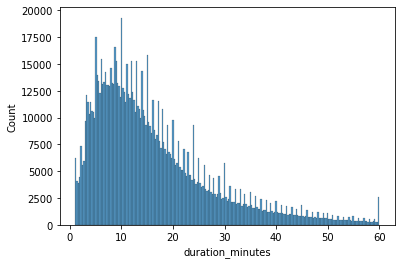

In [6]:
import seaborn as sns
sns.histplot(df_jan_filtered["duration_minutes"])

In [7]:
df_jan_filtered["PUlocationID"] = df_jan_filtered["PUlocationID"].fillna(value=-1)
df_jan_filtered["DOlocationID"] = df_jan_filtered["DOlocationID"].fillna(value=-1)

C:\Users\papageorge\AppData\Local\Temp\ipykernel_11284\2228171213.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jan_filtered["PUlocationID"] = df_jan_filtered["PUlocationID"].fillna(value=-1)
C:\Users\papageorge\AppData\Local\Temp\ipykernel_11284\2228171213.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jan_filtered["DOlocationID"] = df_jan_filtered["DOlocationID"].fillna(value=-1)


In [8]:
missing_pickup_location_perc = (df_jan_filtered["PUlocationID"] == -1).sum() / df_jan_filtered.shape[0]
print(f"The fraction of missing for the pick up location ID is {missing_pickup_location_perc*100}%")

The fraction of missing for the pick up location ID is 83.52732770722618%


In [9]:
from sklearn.feature_extraction import DictVectorizer

df_jan_filtered["PUlocationID"] = df_jan_filtered["PUlocationID"].astype(str)
df_jan_filtered["DOlocationID"] = df_jan_filtered["DOlocationID"].astype(str)

C:\Users\papageorge\AppData\Local\Temp\ipykernel_11284\790358367.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jan_filtered["PUlocationID"] = df_jan_filtered["PUlocationID"].astype(str)
C:\Users\papageorge\AppData\Local\Temp\ipykernel_11284\790358367.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jan_filtered["DOlocationID"] = df_jan_filtered["DOlocationID"].astype(str)


In [10]:
features = ["PUlocationID", "DOlocationID"]
list_of_dicts = df_jan_filtered[features].to_dict(orient="records")

In [11]:
dict_vect = DictVectorizer()
X_train = dict_vect.fit_transform(list_of_dicts)

In [12]:
X_train

<1109826x525 sparse matrix of type '<class 'numpy.float64'>'
	with 2219652 stored elements in Compressed Sparse Row format>

In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X=X_train, y=df_jan_filtered["duration_minutes"])

In [14]:
y_pred_train = lr.predict(X_train)

In [15]:
from sklearn.metrics import mean_squared_error

rmse_train = mean_squared_error(df_jan_filtered["duration_minutes"], y_pred_train, squared=False)
print(f"RMSE on train set: {rmse_train}")

RMSE on train set: 10.5285194284187


### Validation set

In [16]:
df_feb.shape

(1037692, 7)

In [17]:
df_feb["duration_minutes"] = calculate_duration(df=df_feb)

In [18]:
df_feb_filtered  = df_feb[df_feb["duration_minutes"].between(1, 60, inclusive="both")]

In [19]:
df_feb_filtered["PUlocationID"] = df_feb_filtered["PUlocationID"].fillna(value=-1)
df_feb_filtered["DOlocationID"] = df_feb_filtered["DOlocationID"].fillna(value=-1)

C:\Users\papageorge\AppData\Local\Temp\ipykernel_11284\708420111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feb_filtered["PUlocationID"] = df_feb_filtered["PUlocationID"].fillna(value=-1)
C:\Users\papageorge\AppData\Local\Temp\ipykernel_11284\708420111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feb_filtered["DOlocationID"] = df_feb_filtered["DOlocationID"].fillna(value=-1)


In [20]:
df_feb_filtered["PUlocationID"] = df_feb_filtered["PUlocationID"].astype(str)
df_feb_filtered["DOlocationID"] = df_feb_filtered["DOlocationID"].astype(str)

C:\Users\papageorge\AppData\Local\Temp\ipykernel_11284\3996210933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feb_filtered["PUlocationID"] = df_feb_filtered["PUlocationID"].astype(str)
C:\Users\papageorge\AppData\Local\Temp\ipykernel_11284\3996210933.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feb_filtered["DOlocationID"] = df_feb_filtered["DOlocationID"].astype(str)


In [21]:
list_of_dicts_validation = df_feb_filtered[features].to_dict(orient="records")

In [22]:
X_val = dict_vect.transform(list_of_dicts_validation)

In [23]:
y_pred_val = lr.predict(X_val)

In [24]:
rmse_val = mean_squared_error(df_feb_filtered["duration_minutes"], y_pred_val, squared=False)
print(f"RMSE on validation set: {rmse_val}")

RMSE on validation set: 12.559206099038601
